# Workshop 2 - Training Pipeline (Fashion-MNIST, Team 3)

Documentation notebook for the training stage of Workshop 2. It covers the full pipeline end to end - data preparation, model definition, training strategy, monitoring, test-set evaluation and checkpoint verification - and doubles as a runnable reference: every cell calls the same code as the CLI (`src.data`, `src.model`, `src.train`), so the flow shown here is the flow behind the reported results.

**How this notebook is meant to be used**

- `DEMO = True` runs a short 2-epoch demonstration on CPU (about 3 minutes). Demo artifacts are isolated in `runs/notebook_demo/` and `checkpoints/notebook_demo/`, so the real checkpoints and logs are never overwritten.
- The full experiments are launched from the command line (Section 10): SmallCNN, 30 epochs, from scratch; ResNet-18, 20 epochs, ImageNet transfer with two-stage fine-tuning.
- Requirement mapping: architecture and parameter count (Section 3), training strategy (Section 4), monitoring (Sections 5-6), evaluation and comparison (Sections 7-8), saved-model verification (Section 9).

## 0. Configuration

Centralized run parameters, so a change here is enough to reproduce a different configuration:

| Parameter | Demo value | Full runs |
|---|---|---|
| `MODEL` | `"smallcnn"` | `"smallcnn"` / `"resnet18"` |
| `DEMO_EPOCHS` | 2 | 30 (SmallCNN) / 20 (ResNet-18) |
| `BATCH_SIZE` | 128 | 128; GPU ResNet-18 uses 32 (4 GB VRAM limit) |
| `LR` | 1e-3 | 1e-3 Adam (SmallCNN); 3e-4 (ResNet-18) |
| `WEIGHT_DECAY` | 1e-4 | same |
| `SEED` | 42 | same |

`NUM_WORKERS = 0` keeps the DataLoader single-process, the reliable option for notebooks on Windows.

In [1]:
DEMO = True                  # False -> same schedule as the real CLI runs
MODEL = "smallcnn"           # "smallcnn" | "resnet18"
DEMO_EPOCHS = 2 if DEMO else 30
BATCH_SIZE = 128
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 42
NUM_WORKERS = 0              # notebooks: keep 0 for reliability on Windows

## 1. Environment

The notebook runs on the project virtual environment (`Workshop_2/.venv`, installed with `pip install -e .`). The cell below reports the python/torch versions and selects the accelerator through `src.train.pick_device`, which prefers CUDA, then Apple MPS, then the DirectML GPU when available, and otherwise falls back to CPU.

Reproducibility starts here: `seed_everything` fixes the python, numpy and torch RNGs (seed 42), and the data split is cached in `data/splits.json` and reloaded instead of recomputed.

In [2]:
import json
import os
import sys
import time
from pathlib import Path

if Path.cwd().name == "notebooks":       # allow running from notebooks/ or Workshop_2/
    os.chdir("..")
BASE = Path.cwd()
if str(BASE) not in sys.path:
    sys.path.insert(0, str(BASE))

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

from src.data import CLASS_NAMES, build_dataloaders
from src.model import build_model, count_parameters
from src.train import evaluate, pick_device, seed_everything, train_one_epoch

%matplotlib inline

seed_everything(SEED)
device = pick_device("auto")
print(f"python {sys.version.split()[0]} | torch {torch.__version__} | device: {device}")

python 3.11.9 | torch 2.14.0+cpu | device: cpu


## 2. Data - protocol shared with Workshop 1

The dataset is Fashion-MNIST (70,000 grayscale 28x28 images, 10 balanced classes). The pipeline reads the original IDX files from `Workshop_1/code/data` when present and only falls back to a torchvision download otherwise.

| Item | Value |
|---|---|
| Split | stratified 70/15/15 - 49,000 / 10,500 / 10,500 (seed 42) |
| Normalization | global Fashion-MNIST stats: mean 0.2860, std 0.3530 (from the W1 EDA) |
| Augmentation (train only) | horizontal flip p=0.5 + random translation 10% |
| ResNet-18 input | grayscale replicated to RGB, resized to 224x224, ImageNet normalization |

Keeping the identical split and metrics as Workshop 1 means the baseline comparison table can be built without re-running anything.

In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    MODEL, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, augment=True, seed=SEED
)

print(
    f"train={len(train_loader.dataset):,}  "
    f"val={len(val_loader.dataset):,}  "
    f"test={len(test_loader.dataset):,} samples"
)

images, labels = next(iter(train_loader))
print("batch:", tuple(images.shape), "| labels:", labels[:8].tolist())

[data] reusing cached split from data\splits.json
train=49,000  val=10,500  test=10,500 samples
batch: (128, 1, 28, 28) | labels: [3, 1, 5, 6, 9, 2, 8, 0]


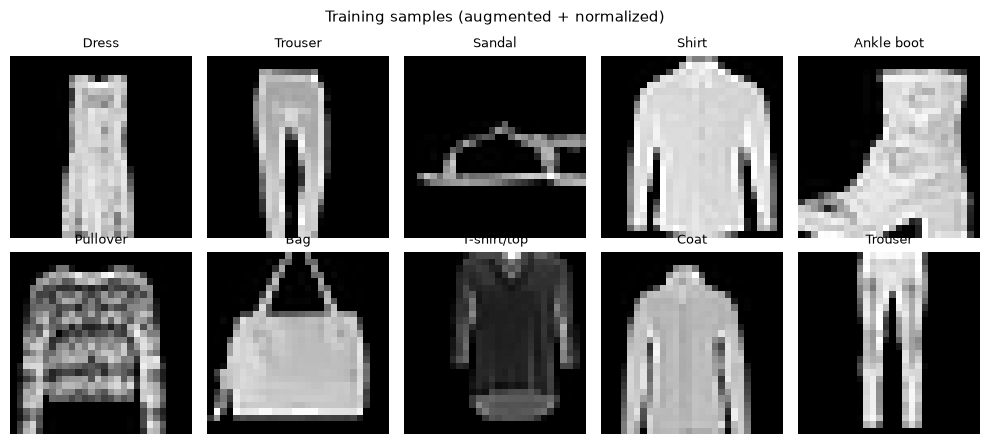

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, img, label in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(img.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[int(label)], fontsize=9)
    ax.axis("off")
fig.suptitle("Training samples (augmented + normalized)", fontsize=11)
fig.tight_layout()

## 3. Model - architecture and parameter count

Two tracks are implemented in `src/model.py`:

| Model | Architecture | Parameters |
|---|---|---|
| `smallcnn` | 3 conv blocks (32 -> 64 -> 128), two conv layers in the first two blocks, BatchNorm + ReLU, 2x2 max-pooling, global average pooling, dropout 0.5, linear head | 140,458 |
| `resnet18` | ImageNet-pretrained torchvision ResNet-18 with a fresh 10-class head; supports two-stage fine-tuning | 11,181,642 |

Convolutions use Kaiming/He initialization (appropriate for ReLU) and the linear head uses Xavier; BatchNorm starts at gamma=1, beta=0. The cell below prints the parameter count and validates the forward pass on one batch, which is the implementation check required by the workshop.

In [5]:
model = build_model(MODEL, pretrained=(MODEL == "resnet18")).to(device)
trainable, total = count_parameters(model)
print(f"{MODEL}: trainable={trainable:,} | total={total:,} parameters")

model.eval()
with torch.no_grad():
    logits = model(images[:4].to(device))
print("forward output:", tuple(logits.shape))
assert logits.shape == (4, len(CLASS_NAMES)), "unexpected output shape"

smallcnn: trainable=140,458 | total=140,458 parameters
forward output: (4, 10)


## 4. Training strategy

| Component | Choice | Notes |
|---|---|---|
| Loss | cross-entropy | label smoothing and mixup are available in the CLI as optional ablations |
| Optimizer | Adam, lr 1e-3, weight decay 1e-4 | SGD + momentum 0.9 selectable via `--optimizer sgd` |
| Schedule | cosine annealing over the full run | smooth decay to near zero; no warm restarts needed at this scale |
| Regularization | BatchNorm + dropout 0.5 + weight decay | combined with the augmentation in Section 2 |
| ResNet-18 | freeze backbone 5 epochs, then fine-tune 15 epochs at lr 3e-4 | two-stage recipe suggested by the workshop guide |

The cell below builds the loss, optimizer and scheduler, prints the resolved configuration and prepares the output folders for the demo run.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=DEMO_EPOCHS)

run_dir = BASE / "runs" / "notebook_demo"
ckpt_dir = BASE / "checkpoints" / "notebook_demo"
run_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir.mkdir(parents=True, exist_ok=True)

config = dict(
    model=MODEL, epochs=DEMO_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    weight_decay=WEIGHT_DECAY, optimizer="adam", scheduler="cosine", seed=SEED,
)
print(json.dumps(config, indent=2))

{
  "model": "smallcnn",
  "epochs": 2,
  "batch_size": 128,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "optimizer": "adam",
  "scheduler": "cosine",
  "seed": 42
}


## 5. Training loop

Each epoch performs the same four steps as `src/train.py`:

1. One training pass with augmentation (loss, backward, optimizer step).
2. A validation pass without augmentation or gradients, computing loss, accuracy and macro precision/recall/F1.
3. A cosine scheduler step.
4. Checkpoint update: whenever validation macro-F1 improves, the full training state (`state_dict`, class names, epoch, validation metrics) is written to `checkpoints/notebook_demo/model_best.pt`.

The CLI version adds early stopping (patience 8 on validation macro-F1) and per-epoch CSV/TensorBoard logging; in the notebook the history is kept in memory and also saved as JSON.

In [7]:
history = []
best_f1, best_epoch = -1.0, -1

for epoch in range(1, DEMO_EPOCHS + 1):
    t0 = time.time()
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_f1_macro": val_metrics["f1_macro"],
        "time_s": time.time() - t0,
    }
    history.append(row)

    if val_metrics["f1_macro"] > best_f1:
        best_f1, best_epoch = val_metrics["f1_macro"], epoch
        torch.save(
            {
                "model_name": MODEL,
                "state_dict": model.state_dict(),
                "classes": CLASS_NAMES,
                "epoch": epoch,
                "val_metrics": val_metrics,
            },
            ckpt_dir / "model_best.pt",
        )

    print(
        f"epoch {epoch:02d}/{DEMO_EPOCHS} | lr {row['lr']:.2e} | "
        f"train loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} | "
        f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.4f} "
        f"f1 {row['val_f1_macro']:.4f} | {row['time_s']:.1f}s"
    )

print(f"\nbest val macro-F1 {best_f1:.4f} at epoch {best_epoch} -> {ckpt_dir / 'model_best.pt'}")
(run_dir / "train_log.json").write_text(json.dumps(history, indent=2))

epoch 01/2 | lr 5.00e-04 | train loss 0.8159 acc 0.7083 | val loss 0.5254 acc 0.8010 f1 0.7866 | 70.3s


epoch 02/2 | lr 0.00e+00 | train loss 0.5110 acc 0.8157 | val loss 0.3933 acc 0.8591 f1 0.8604 | 70.2s

best val macro-F1 0.8604 at epoch 2 -> C:\Users\jhoja\Documents\Universidad\Semestre 10\Machine-Learning\MachineLearning\Workshop_2\checkpoints\notebook_demo\model_best.pt


516

## 6. Monitoring - learning curves

The plots show training/validation loss and accuracy plus validation macro-F1 per epoch - the same signals logged to `runs/train_log.csv` and TensorBoard in the full runs. What to look for:

- Train vs validation gap: a large gap would indicate overfitting and suggest stronger regularization.
- Both losses still decreasing when the schedule ends: the run could benefit from more epochs.
- Macro-F1 is the checkpoint selection metric, so its curve is the decision signal.

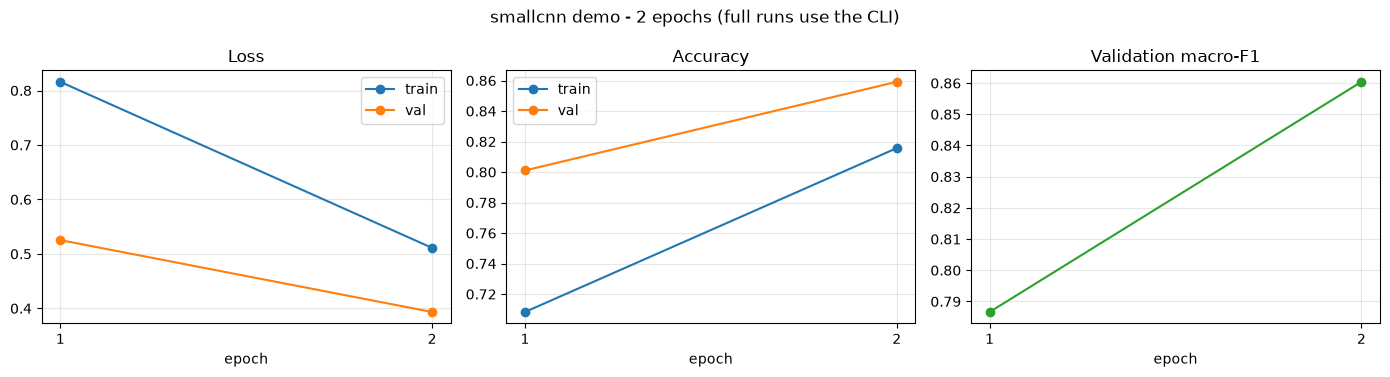

In [8]:
epochs = [r["epoch"] for r in history]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(epochs, [r["train_loss"] for r in history], marker="o", label="train")
axes[0].plot(epochs, [r["val_loss"] for r in history], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs, [r["train_acc"] for r in history], marker="o", label="train")
axes[1].plot(epochs, [r["val_acc"] for r in history], marker="o", label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(epochs, [r["val_f1_macro"] for r in history], marker="o", color="tab:green")
axes[2].set_title("Validation macro-F1")
axes[2].set_xlabel("epoch")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xticks(epochs)

fig.suptitle(f"{MODEL} demo - {DEMO_EPOCHS} epochs (full runs use the CLI)")
fig.tight_layout()
fig.savefig(run_dir / "learning_curves_demo.png", dpi=150)

## 7. Test-set evaluation

The best demo checkpoint is reloaded and evaluated on the held-out test split (10,500 images never used for training or model selection). Metrics follow the Workshop 1 protocol:

- **Accuracy** - overall fraction of correct predictions.
- **Macro F1** - unweighted mean of the per-class F1 scores; the classes are balanced (imbalance ratio 1.00), so it mainly documents per-class quality.
- **ROC-AUC (OvR, macro)** - ranking quality aggregated over the ten one-vs-rest problems; less sensitive to the decision threshold than accuracy.

The confusion matrix that follows exposes systematic errors: in both full runs the upper-body garments (Shirt, T-shirt/top, Pullover, Coat) are the hardest group.

In [9]:
ckpt = torch.load(ckpt_dir / "model_best.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.to(device).eval()

preds_list, labels_list, probs_list = [], [], []
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        logits = model(batch_images.to(device))
        preds_list.append(logits.argmax(dim=1).cpu())
        probs_list.append(torch.softmax(logits, dim=1).cpu())
        labels_list.append(batch_labels)

preds = torch.cat(preds_list).numpy()
labels = torch.cat(labels_list).numpy()
probs = torch.cat(probs_list).numpy()

test_metrics = {
    "accuracy": float(accuracy_score(labels, preds)),
    "f1_macro": float(f1_score(labels, preds, average="macro")),
    "roc_auc_ovr_macro": float(roc_auc_score(labels, probs, multi_class="ovr", average="macro")),
}
print(json.dumps(test_metrics, indent=2))
print()
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))
(run_dir / "test_metrics_demo.json").write_text(json.dumps(test_metrics, indent=2))

{
  "accuracy": 0.8525714285714285,
  "f1_macro": 0.853906210971726,
  "roc_auc_ovr_macro": 0.9867512622826909
}

              precision    recall  f1-score   support

 T-shirt/top      0.818     0.786     0.802      1050
     Trouser      0.977     0.968     0.972      1050
    Pullover      0.826     0.757     0.790      1050
       Dress      0.833     0.895     0.863      1050
        Coat      0.791     0.727     0.758      1050
      Sandal      0.985     0.896     0.939      1050
       Shirt      0.552     0.634     0.590      1050
     Sneaker      0.896     0.930     0.913      1050
         Bag      0.978     0.968     0.973      1050
  Ankle boot      0.917     0.965     0.940      1050

    accuracy                          0.853     10500
   macro avg      0.857     0.853     0.854     10500
weighted avg      0.857     0.853     0.854     10500



112

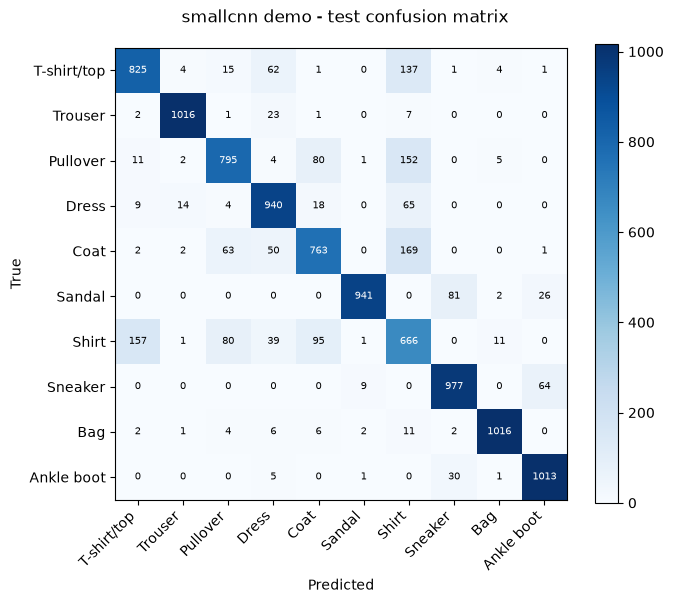

In [10]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j], ha="center", va="center", fontsize=7,
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )
fig.colorbar(im)
fig.suptitle(f"{MODEL} demo - test confusion matrix")
fig.tight_layout()

## 8. Reference results from the full runs

The demo is only a smoke test; the report numbers come from the full experiments. The cell reads their `test_metrics.json` files, and the table below summarizes the comparison with Workshop 1:

| Model | Test accuracy | Macro F1 | ROC-AUC (OvR) |
|---|---|---|---|
| W1 best baseline (HistGradientBoosting) | 87.48% | 0.8740 | - |
| W2 SmallCNN (from scratch, 30 epochs) | 93.05% | 0.9302 | 0.9961 |
| W2 ResNet-18 (ImageNet transfer, 20 epochs) | 94.94% | 0.9494 | 0.9979 |

Both deep models clear the Workshop 1 baseline by a wide margin; ResNet-18 adds about +1.9 points over the from-scratch CNN.

In [11]:
rows = []
for name, path in [
    ("W2 SmallCNN", BASE / "runs" / "test_metrics.json"),
    ("W2 ResNet-18", BASE / "runs" / "resnet18" / "test_metrics.json"),
]:
    if path.exists():
        metrics = json.loads(path.read_text())["metrics"]
        rows.append((name, metrics["accuracy"], metrics["f1_macro"], metrics["roc_auc_ovr_macro"]))

print(f"{'model':<16}{'test acc':>10}{'macro F1':>10}{'ROC-AUC':>10}")
for name, acc, f1, auc in rows:
    print(f"{name:<16}{acc:>10.4f}{f1:>10.4f}{auc:>10.4f}")

model             test acc  macro F1   ROC-AUC
W2 SmallCNN         0.9305    0.9302    0.9961
W2 ResNet-18        0.9494    0.9494    0.9979


## 9. Checkpoint verification (deliverable)

The workshop requires a saved model that can be loaded and used for inference. The check below is the same one as `python -m src.test_model`:

1. Load `checkpoints/model_best.pt` (current final checkpoint: SmallCNN, epoch 29).
2. Rebuild the architecture from the checkpoint metadata and load the weights, checking for missing or unexpected keys.
3. Run a forward pass on a test batch and confirm the output shape.

A clean load with zero missing/unexpected keys is the evidence that the checkpoint is self-contained and reproducible.

In [12]:
verify_path = BASE / "checkpoints" / "model_best.pt"
ck = torch.load(verify_path, map_location="cpu", weights_only=False)
verify_model = build_model(ck["model_name"], num_classes=len(ck["classes"]), pretrained=False)
missing, unexpected = verify_model.load_state_dict(ck["state_dict"], strict=False)
print(
    f"loaded {verify_path.name} | model={ck['model_name']} | epoch={ck['epoch']} | "
    f"missing={len(missing)} unexpected={len(unexpected)}"
)

verify_model.to(device).eval()
with torch.no_grad():
    sample_images, _ = next(iter(test_loader))
    logits = verify_model(sample_images.to(device))
print(f"inference on {sample_images.size(0)} samples -> output {tuple(logits.shape)} [OK]")

loaded model_best.pt | model=smallcnn | epoch=29 | missing=0 unexpected=0
inference on 128 samples -> output (128, 10) [OK]


## 10. Reproducing the full experiments

Commands used for the reported runs:

```bash
# Architecture + forward-pass check
python -m src.model

# SmallCNN from scratch (30 epochs, CPU/MPS)
python -m src.train --model smallcnn --epochs 30

# ResNet-18 ImageNet transfer, two-stage fine-tuning (20 epochs)
# GPU (Windows/AMD DirectML venv) or CPU:
python -m src.train --model resnet18 --epochs 20 --freeze-epochs 5 --lr 3e-4 --batch-size 32 \
    --checkpoint-dir checkpoints/resnet18 --runs-dir runs/resnet18

# Test-set evaluation + checkpoint verification
python -m src.evaluate --checkpoint checkpoints/model_best.pt --plot
python -m src.test_model --checkpoint checkpoints/model_best.pt
```

**Expected artifacts**

- `checkpoints/model_best.pt` - SmallCNN best (epoch 29): 93.05% test accuracy, macro F1 0.9302.
- `checkpoints/resnet18/model_best.pt` - ResNet-18 best (epoch 20): 94.94% test accuracy, macro F1 0.9494.
- `runs/` and `runs/resnet18/` - CSV logs, summaries, learning curves, test metrics, confusion matrices and TensorBoard event files.

**Environment note**: the ResNet-18 run was trained on an AMD RX 6600 (4 GB) through DirectML in a separate `.venv-gpu`; batch 32 at 224x224 is required to fit VRAM (93.4 min for 20 epochs). SmallCNN training and all evaluations run on CPU and reproduce the original numbers bit-for-bit. The GPU setup is documented in `Entorno de trabajo` (ML-Vault).

## 11. Summary

- The notebook and the CLI share one implementation: `src/data.py`, `src/model.py`, `src/train.py`; nothing is duplicated for presentation.
- The demo run validates the flow end to end; the reported metrics come from the full runs (SmallCNN 30 epochs, ResNet-18 20 epochs).
- Reproducibility relies on three things: fixed seeds, the cached stratified split (`data/splits.json`) and the full configuration stored inside every checkpoint.
- Demo artifacts stay isolated in `*_demo/` folders, so the notebook can be re-run at any time without touching the deliverables.